### SETUP

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from pathlib import Path

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# ── Project root detection ──
import sys, os
PROJECT_ROOT = Path(os.getcwd())
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

FIGURES_DIR = PROJECT_ROOT / "data" / "processed" / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri("http://127.0.0.1:5001")

from src.models.features import prepare_data, build_preprocessor, NUMERIC_FEATURES, CATEGORICAL_FEATURES

sns.set_theme(style="whitegrid")

### Load and Prepare Data

In [6]:
X_train, X_test, y_train, y_test, preprocessor = prepare_data()

print(f"Training set: {X_train.shape[0]:,} recipes, {X_train.shape[1]} raw features")
print(f"Test set:     {X_test.shape[0]:,} recipes")
print(f"\nTarget distribution:")
print(y_train.describe())

Training set: 113,819 recipes, 13 raw features
Test set:     28,455 recipes

Target distribution:
count    113819.000000
mean          4.617173
std           0.647009
min           1.000000
25%           4.500000
50%           5.000000
75%           5.000000
max           5.000000
Name: AggregatedRating, dtype: float64


### Defining the Model Training Function

In [7]:
def train_and_evaluate(name, model, X_train, X_test, y_train, y_test, preprocessor):
    """
    Train a model, evaluate it, and log everything to MLflow.

    """
    # Build a pipeline: preprocessing + model
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    # Train
    pipe.fit(X_train, y_train)

    # Predict on test set
    y_pred = pipe.predict(X_test)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Cross-validation (5-fold)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")
    cv_rmse = -cv_scores.mean()

    # Log to MLflow
    with mlflow.start_run(run_name=name):
        mlflow.log_param("model_type", name)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2", r2)
        mlflow.log_metric("cv_rmse", cv_rmse)
        mlflow.sklearn.log_model(pipe, "model")

    metrics = {"Model": name, "RMSE": rmse, "MAE": mae, "R²": r2, "CV RMSE": cv_rmse}
    print(f"{name:20s} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f} | CV RMSE: {cv_rmse:.4f}")

    return metrics, pipe

### Training All Models

In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (α=1.0)": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1,       # Use all CPU cores
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
    ),
}

results = []
trained_models = {}

for name, model in models.items():
    metrics, pipe = train_and_evaluate(
        name, model,
        X_train, X_test, y_train, y_test,
        build_preprocessor(),  # Fresh preprocessor per model
    )
    results.append(metrics)
    trained_models[name] = pipe

# Compare
results_df = pd.DataFrame(results).sort_values("RMSE")
print("\n" + "="*70)
print("Model Comparison (sorted by RMSE — lower is better)")
print("="*70)
print(results_df.to_string(index=False))

2026/03/22 18:05:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 18:05:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/22 18:05:43 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run Linear Regression at: http://127.0.0.1:5001/#/experiments/0/runs/7748a878676f4ecb9e5c34767d52ad73
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/0
Linear Regression    | RMSE: 0.6474 | MAE: 0.4793 | R²: 0.0065 | CV RMSE: 0.6450


2026/03/22 18:05:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 18:05:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/22 18:05:45 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run Ridge (α=1.0) at: http://127.0.0.1:5001/#/experiments/0/runs/9c334f28c2f84cb8b2828d66e32c0545
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/0
Ridge (α=1.0)        | RMSE: 0.6473 | MAE: 0.4793 | R²: 0.0069 | CV RMSE: 0.6449


2026/03/22 18:06:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 18:06:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/22 18:06:32 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run Random Forest at: http://127.0.0.1:5001/#/experiments/0/runs/2b50d3f89648443f94b35958056cde4e
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/0
Random Forest        | RMSE: 0.6322 | MAE: 0.4657 | R²: 0.0526 | CV RMSE: 0.6284


2026/03/22 18:06:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 18:06:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/22 18:06:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run XGBoost at: http://127.0.0.1:5001/#/experiments/0/runs/7286998729a3477495fe2de0d14dada6
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/0
XGBoost              | RMSE: 0.6313 | MAE: 0.4633 | R²: 0.0552 | CV RMSE: 0.6276

Model Comparison (sorted by RMSE — lower is better)
            Model     RMSE      MAE       R²  CV RMSE
          XGBoost 0.631320 0.463292 0.055234 0.627582
    Random Forest 0.632214 0.465715 0.052556 0.628431
    Ridge (α=1.0) 0.647278 0.479254 0.006866 0.644855
Linear Regression 0.647404 0.479266 0.006480 0.644970


### Visualizing Results

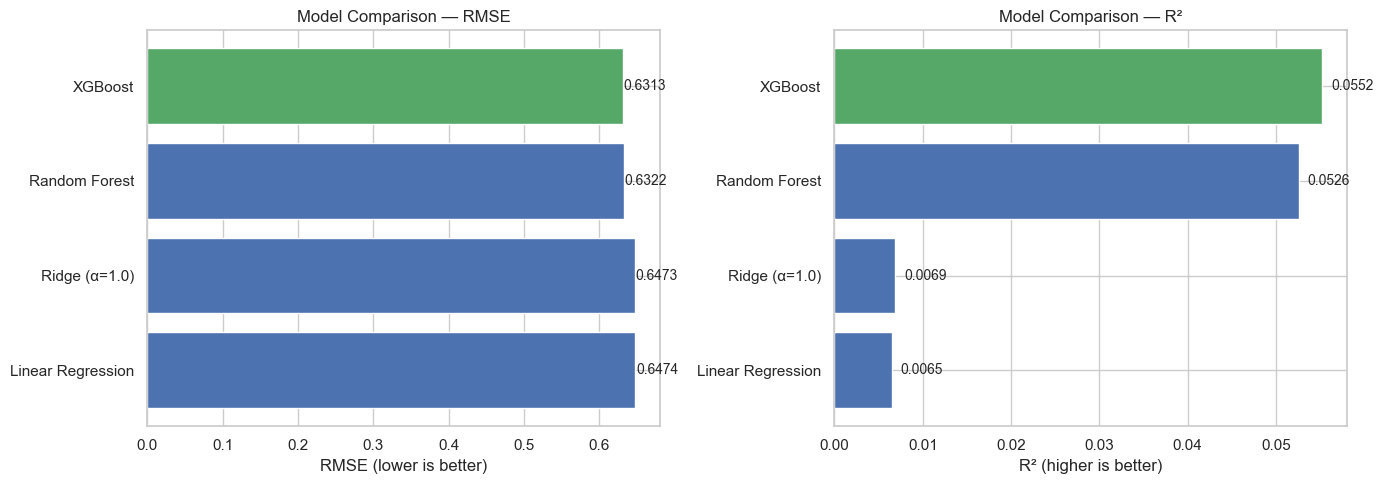

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of RMSE
ax = axes[0]
colors = ["#55A868" if r == results_df["RMSE"].min() else "#4C72B0" for r in results_df["RMSE"]]
ax.barh(results_df["Model"], results_df["RMSE"], color=colors)
ax.set_xlabel("RMSE (lower is better)")
ax.set_title("Model Comparison — RMSE")
ax.invert_yaxis()
for i, v in enumerate(results_df["RMSE"]):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=10)

# Bar chart of R²
ax = axes[1]
colors = ["#55A868" if r == results_df["R²"].max() else "#4C72B0" for r in results_df["R²"]]
ax.barh(results_df["Model"], results_df["R²"], color=colors)
ax.set_xlabel("R² (higher is better)")
ax.set_title("Model Comparison — R²")
ax.invert_yaxis()
for i, v in enumerate(results_df["R²"]):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_model_comparison.png", bbox_inches="tight")
plt.show()

### Feature Importance (Best Model)

Best model: XGBoost


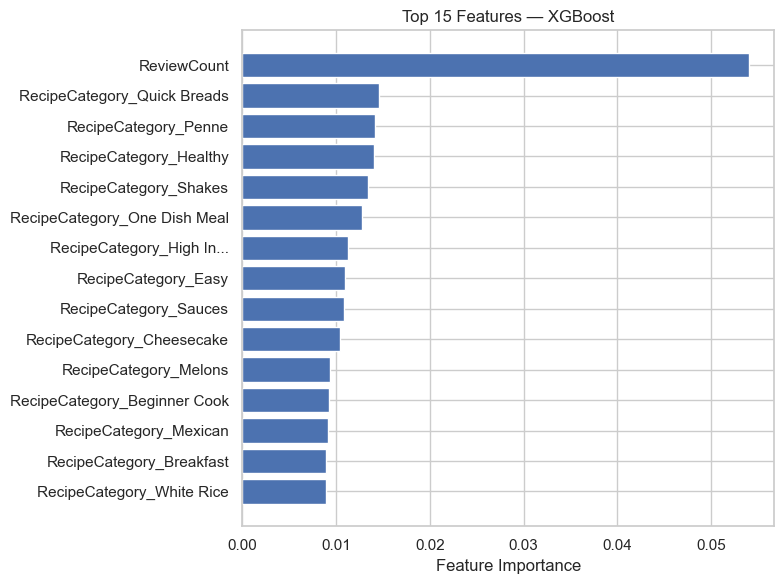

In [10]:
# Get the best model (lowest RMSE)
best_name = results_df.iloc[0]["Model"]
best_pipe = trained_models[best_name]

print(f"Best model: {best_name}")

# Extract feature names after preprocessing
preprocessor_fitted = best_pipe.named_steps["preprocessor"]
feature_names = NUMERIC_FEATURES.copy()

# Add one-hot encoded category names
if hasattr(preprocessor_fitted.transformers_[1][1], "get_feature_names_out"):
    cat_names = preprocessor_fitted.transformers_[1][1].get_feature_names_out(CATEGORICAL_FEATURES)
    feature_names.extend(cat_names)

# Get feature importances (works for tree models)
model = best_pipe.named_steps["model"]
if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    importance_df = pd.DataFrame({
        "Feature": feature_names[:len(importances)],
        "Importance": importances,
    }).sort_values("Importance", ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(importance_df["Feature"], importance_df["Importance"], color="#4C72B0")
    ax.set_xlabel("Feature Importance")
    ax.set_title(f"Top 15 Features — {best_name}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "10_feature_importance.png", bbox_inches="tight")
    plt.show()
else:
    print(f"{best_name} doesn't have feature_importances_. Use coefficients instead.")
    # For linear models, use absolute coefficients
    coefs = np.abs(model.coef_)
    importance_df = pd.DataFrame({
        "Feature": feature_names[:len(coefs)],
        "Abs Coefficient": coefs,
    }).sort_values("Abs Coefficient", ascending=True).tail(15)
    print(importance_df.to_string(index=False))

### Prediction Analysis

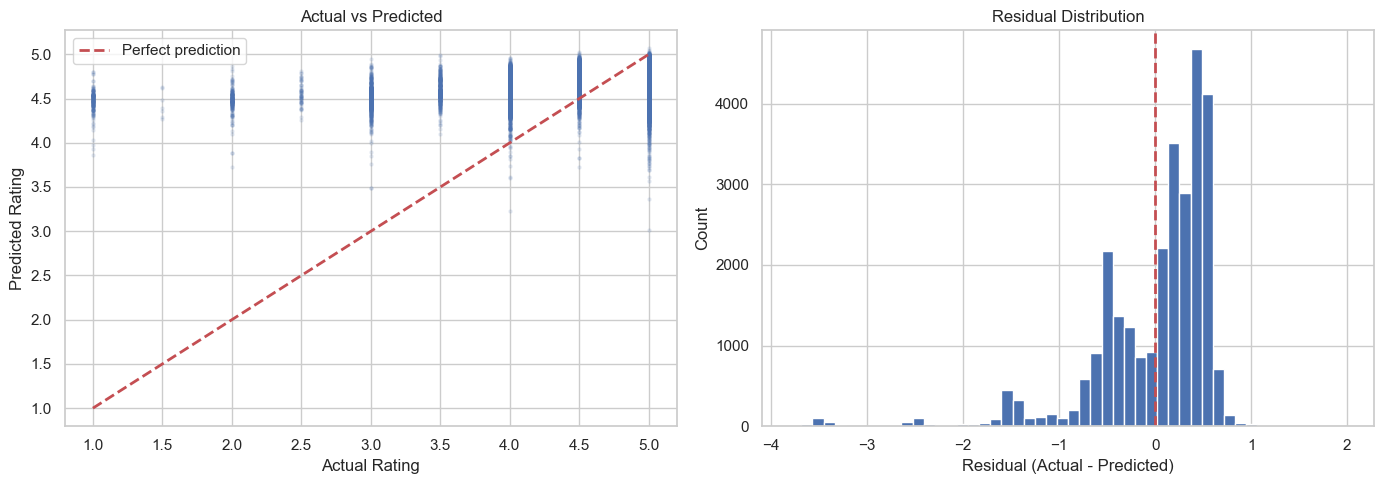


Mean residual: 0.0032 (should be ~0)
Std residual:  0.6313


In [11]:
# Predicting on test set with best model
y_pred = best_pipe.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.1, s=5, color="#4C72B0")
ax.plot([1, 5], [1, 5], "--", color="#C44E52", linewidth=2, label="Perfect prediction")
ax.set_xlabel("Actual Rating")
ax.set_ylabel("Predicted Rating")
ax.set_title("Actual vs Predicted")
ax.legend()

# Residual distribution
ax = axes[1]
residuals = y_test - y_pred
ax.hist(residuals, bins=50, color="#4C72B0", edgecolor="white")
ax.axvline(0, color="#C44E52", linestyle="--", linewidth=2)
ax.set_xlabel("Residual (Actual - Predicted)")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "11_prediction_analysis.png", bbox_inches="tight")
plt.show()

print(f"\nMean residual: {residuals.mean():.4f} (should be ~0)")
print(f"Std residual:  {residuals.std():.4f}")

### Saving the Best Model

In [12]:
import joblib

# Save the full pipeline (preprocessor + model)
best_model_file = MODELS_DIR / "rating_predictor.joblib"
joblib.dump(best_pipe, best_model_file)
print(f"Saved best model to {best_model_file}")
print(f"File size: {best_model_file.stat().st_size / 1024 / 1024:.1f} MB")

# Quick test: load and predict
loaded = joblib.load(best_model_file)
test_pred = loaded.predict(X_test[:5])
print(f"\nSample predictions: {test_pred.round(2)}")
print(f"Actual values:     {y_test[:5].values.round(2)}")

Saved best model to /Users/ehtishamaziz/Development/Data Science & AI Projects/RecipeIQ/models/rating_predictor.joblib
File size: 0.7 MB

Sample predictions: [4.83 4.43 4.53 4.55 4.81]
Actual values:     [5.  4.  5.  5.  4.5]
